In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

output_path = "output/simulated_events_100.parquet"

events = pd.read_parquet(output_path)

print(f"Number of events: {len(events)}")
events.head()

Number of events: 100


,mc_truth,photons
0,"{'interaction': 1, 'initial_state_energy': 28....","{'sensor_pos_x': [113.19, 62.91, 89.47, 14.48,..."
1,"{'interaction': 2, 'initial_state_energy': 47....","{'sensor_pos_x': [210.47, 124.97], 'sensor_pos..."
2,"{'interaction': 2, 'initial_state_energy': 35....","{'sensor_pos_x': [62.91, 62.91, 62.91, -9.68, ..."
3,"{'interaction': 1, 'initial_state_energy': 13....","{'sensor_pos_x': [14.48], 'sensor_pos_y': [-82..."
4,"{'interaction': 2, 'initial_state_energy': 14....","{'sensor_pos_x': [-10.97, 18.51, 14.48, 27.12,..."


In [2]:
events["n_hits"] = events["photons"].apply(lambda x: len(x["t"]))

events["n_hits"].describe()

count     100.000000
mean       97.930000
std       174.781899
min         0.000000
25%        15.750000
50%        35.500000
75%        91.750000
max      1170.000000
Name: n_hits, dtype: float64

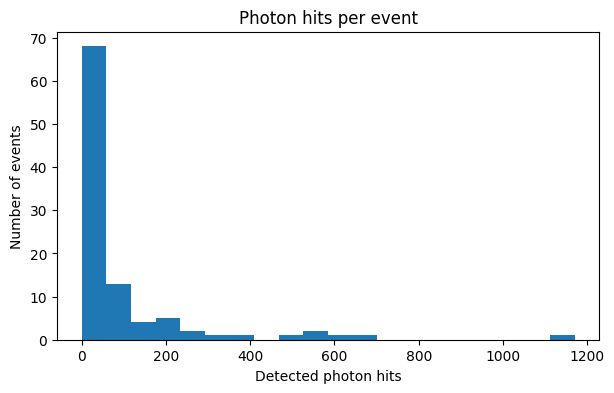

In [3]:
plt.figure(figsize=(7, 4))
plt.hist(events["n_hits"], bins=20)

plt.xlabel("Detected photon hits")
plt.ylabel("Number of events")
plt.title("Photon hits per event")
plt.show()

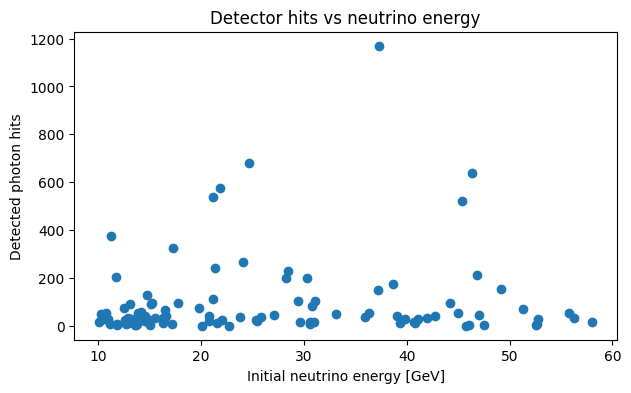

In [4]:
events["neutrino_energy"] = events["mc_truth"].apply(
    lambda x: x["initial_state_energy"]
)

plt.figure(figsize=(7, 4))
plt.scatter(events["neutrino_energy"], events["n_hits"])

plt.xlabel("Initial neutrino energy [GeV]")
plt.ylabel("Detected photon hits")
plt.title("Detector hits vs neutrino energy")
plt.show()

In [5]:
event_idx = events["n_hits"].idxmax()
event = events.loc[event_idx]

truth = event["mc_truth"]
photons = event["photons"]

print("Event index:", event_idx)
print("Neutrino energy:", truth["initial_state_energy"], "GeV")
print("Neutrino PDG:", truth["initial_state_type"])
print("Interaction:", truth["interaction"])
print("Number of final-state particles:", len(truth["final_state_type"]))
print("Number of photon hits:", len(photons["t"]))

Event index: 65
Neutrino energy: 37.254440906107355 GeV
Neutrino PDG: 14
Interaction: 2
Number of final-state particles: 6
Number of photon hits: 1170


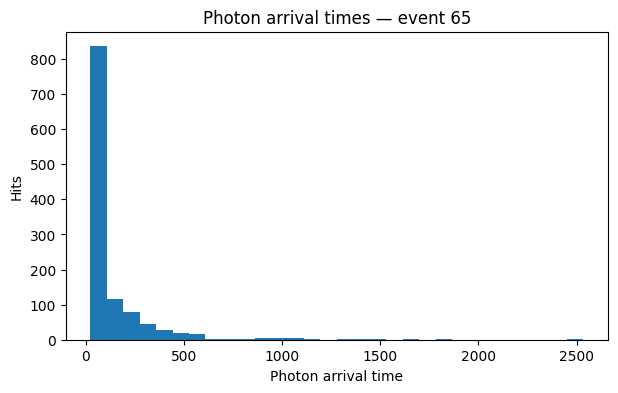

In [6]:
plt.figure(figsize=(7, 4))
plt.hist(photons["t"], bins=30)

plt.xlabel("Photon arrival time")
plt.ylabel("Hits")
plt.title(f"Photon arrival times — event {event_idx}")
plt.show()

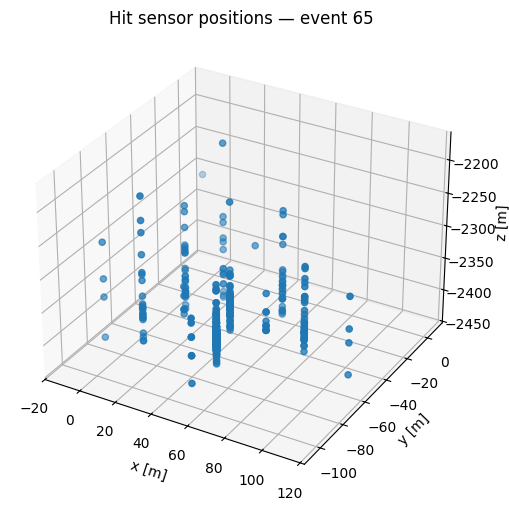

In [7]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")

ax.scatter(
    photons["sensor_pos_x"],
    photons["sensor_pos_y"],
    photons["sensor_pos_z"],
    s=20,
)

ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")
ax.set_title(f"Hit sensor positions — event {event_idx}")

plt.show()

In [8]:
hit_df = pd.DataFrame({
    "x": photons["sensor_pos_x"],
    "y": photons["sensor_pos_y"],
    "z": photons["sensor_pos_z"],
    "string_id": photons["string_id"],
    "sensor_id": photons["sensor_id"],
    "t": photons["t"],
})

sensor_hits = (
    hit_df
    .groupby(["string_id", "sensor_id", "x", "y", "z"], as_index=False)
    .agg(
        n_hits=("t", "size"),
        first_hit_time=("t", "min"),
    )
)

sensor_hits.head()

,string_id,sensor_id,x,y,z,n_hits,first_hit_time
0,36,52,46.29,-34.88,-2315.15,1,440.337128
1,79,43,31.25,-72.93,-2331.47,1,270.378418
2,79,45,31.25,-72.93,-2345.49,1,525.756958
3,79,48,31.25,-72.93,-2366.52,3,181.136719
4,79,49,31.25,-72.93,-2373.52,1,129.303192


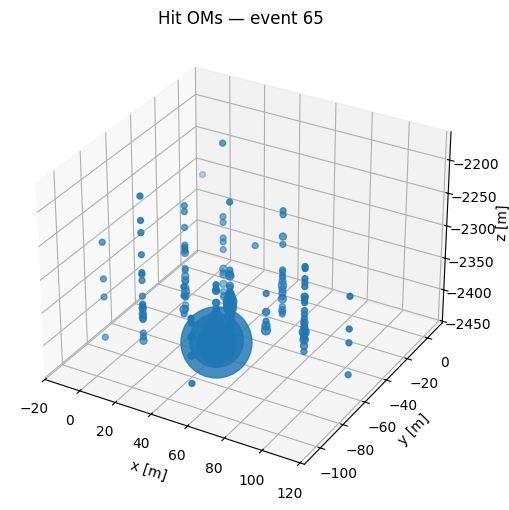

In [9]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")

ax.scatter(
    sensor_hits["x"],
    sensor_hits["y"],
    sensor_hits["z"],
    s=10 + 8 * sensor_hits["n_hits"],
)

ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")
ax.set_title(f"Hit OMs — event {event_idx}")

plt.show()